In [1]:
!pip install shap scikit-learn pandas matplotlib -q

In [5]:
!pip install python-docx -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 5.4 MB/s eta 0:00:00


In [7]:
from docx import Document

# Path to your uploaded .docx file
docx_file_path = "medical_diagnosis_dataset.csv.docx"

try:
    document = Document(docx_file_path)
    full_text = []
    for para in document.paragraphs:
        full_text.append(para.text)

    # Join all paragraphs into a single string
    document_content = '\n'.join(full_text)
    print("--- Document Content ---")
    print(document_content[:1000]) # Print first 1000 characters to avoid overwhelming output
    print("\n--- End of Document Content Sample ---")

except Exception as e:
    print(f"Error reading .docx file: {e}")

--- Document Content ---
patient_name,email,phone_number,address,national_id,age,blood_pressure,cholesterol,glucose,bmi,diagnosis
John Doe,john@example.com,9876543210,London,UK12345,45,130,220,110,28,1
Jane Smith,jane@example.com,9876543211,Paris,FR54321,50,145,240,120,31,1
Alex Brown,alex@example.com,9876543212,Berlin,DE67890,38,120,180,95,24,0
Emily White,emily@example.com,9876543213,Madrid,ES24680,60,155,260,140,34,1
Michael Green,michael@example.com,9876543214,Rome,IT13579,42,125,200,100,26,0
Sarah Lee,sarah@example.com,9876543215,Amsterdam,NL11223,55,150,250,135,33,1
David Clark,david@example.com,9876543216,Brussels,BE44556,36,118,175,90,23,0
Olivia Hall,olivia@example.com,9876543217,Vienna,AT77889,48,140,230,118,30,1
James Young,james@example.com,9876543218,Prague,CZ99001,40,122,190,98,25,0
Sophia King,sophia@example.com,9876543219,Dublin,IE22334,58,152,255,138,32,1

--- End of Document Content Sample ---


In [8]:
import io
import pandas as pd

df = pd.read_csv(io.StringIO(document_content))

print(df.head())

    patient_name                email  phone_number address national_id  age  \
0       John Doe     john@example.com    9876543210  London     UK12345   45   
1     Jane Smith     jane@example.com    9876543211   Paris     FR54321   50   
2     Alex Brown     alex@example.com    9876543212  Berlin     DE67890   38   
3    Emily White    emily@example.com    9876543213  Madrid     ES24680   60   
4  Michael Green  michael@example.com    9876543214    Rome     IT13579   42   

   blood_pressure  cholesterol  glucose  bmi  diagnosis  
0             130          220      110   28          1  
1             145          240      120   31          1  
2             120          180       95   24          0  
3             155          260      140   34          1  
4             125          200      100   26          0  


In [2]:
from google.colab import files

uploaded = files.upload()

Saving medical_diagnosis_dataset.csv.docx to medical_diagnosis_dataset.csv.docx


In [4]:
import pandas as pd

df = pd.read_csv(
    "medical_diagnosis_dataset.csv.docx"
)

print(df.head())

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xd2 in position 16: invalid continuation byte

In [10]:
# =====================================================
# REMOVE GDPR-SENSITIVE COLUMNS
# =====================================================

sensitive_columns = [

    "patient_name",

    "email",

    "phone_number",

    "address",

    "national_id"
]

df = df.drop(
    columns=sensitive_columns,
    errors="ignore"
)

print("Sensitive data removed!")

print(df.head())

Sensitive data removed!
   age  blood_pressure  cholesterol  glucose  bmi  diagnosis
0   45             130          220      110   28          1
1   50             145          240      120   31          1
2   38             120          180       95   24          0
3   60             155          260      140   34          1
4   42             125          200      100   26          0


In [11]:
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

# =====================================================
# FEATURES & TARGET
# =====================================================

X = df.drop(
    "diagnosis",
    axis=1
)

y = df["diagnosis"]

# =====================================================
# TRAIN TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =====================================================
# TRAIN MODEL
# =====================================================

model = RandomForestClassifier()

model.fit(X_train, y_train)

# =====================================================
# PREDICTIONS
# =====================================================

predictions = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    predictions
)

print("Model Accuracy:", accuracy)

Model Accuracy: 1.0


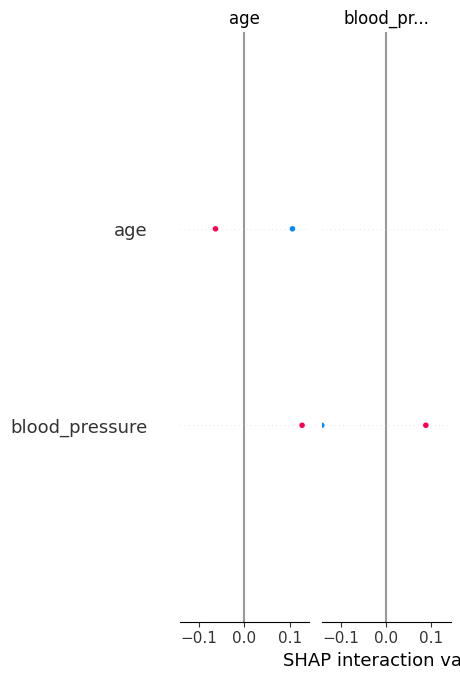

In [12]:
import shap

# =====================================================
# CREATE EXPLAINER
# =====================================================

explainer = shap.TreeExplainer(model)

# =====================================================
# SHAP VALUES
# =====================================================

shap_values = explainer.shap_values(X_test)

# =====================================================
# SUMMARY PLOT
# =====================================================

shap.summary_plot(
    shap_values,
    X_test
)

In [13]:
import matplotlib.pyplot as plt

plt.savefig(
    "shap_dashboard.png",
    bbox_inches="tight"
)

print("Dashboard Saved!")

Dashboard Saved!


<Figure size 640x480 with 0 Axes>